# **Classification**

In [1]:
# Install
!pip install pyspark

from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("ClassificationAdvanced").getOrCreate()

In [3]:
# Imports
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

from sklearn.datasets import load_breast_cancer
import pandas as pd

In [4]:
# Load dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['label'] = data.target

spark_df = spark.createDataFrame(df)

In [5]:
# Feature Engineering
assembler = VectorAssembler(
    inputCols=data.feature_names.tolist(),
    outputCol="features_raw"
)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features"
)

In [6]:
# Model
lr = LogisticRegression(featuresCol="features", labelCol="label")

In [7]:
# Pipeline
pipeline = Pipeline(stages=[assembler, scaler, lr])

In [8]:
# Hyperparameter tuning
paramGrid = ParamGridBuilder() \
    .addGrid(lr.regParam, [0.01, 0.1]) \
    .addGrid(lr.maxIter, [10, 50]) \
    .build()

evaluator = BinaryClassificationEvaluator(labelCol="label")

cv = CrossValidator(
    estimator=pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3
)

In [9]:
# Train-test split
train, test = spark_df.randomSplit([0.8, 0.2], seed=42)

In [10]:
# Train
model = cv.fit(train)


In [12]:
# Predict
predictions = model.transform(test)

In [13]:
# Evaluate
auc = evaluator.evaluate(predictions)
print("AUC Score:", auc)

predictions.select("label", "prediction", "probability").show(5, False)

AUC Score: 1.0
+-----+----------+------------------------------------------+
|label|prediction|probability                               |
+-----+----------+------------------------------------------+
|1    |1.0       |[0.001953793536865936,0.998046206463134]  |
|1    |1.0       |[0.0013668327587256488,0.9986331672412744]|
|1    |1.0       |[4.7645476433995305E-5,0.999952354523566] |
|1    |1.0       |[5.945256679891233E-4,0.9994054743320109] |
|1    |1.0       |[6.054009124522862E-4,0.9993945990875477] |
+-----+----------+------------------------------------------+
only showing top 5 rows


In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

In [15]:
# Convert Spark → Pandas
pred_pd = predictions.select("label", "probability").toPandas()

In [16]:
# Extract probability of class 1
y_true = pred_pd["label"]
y_score = pred_pd["probability"].apply(lambda x: float(x[1]))

In [17]:
# ROC
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)


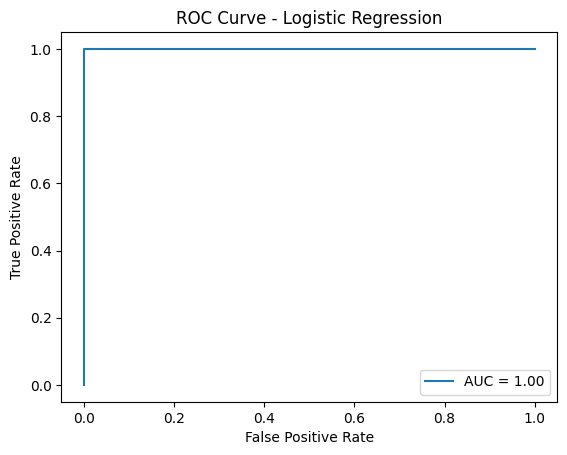

In [18]:
# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

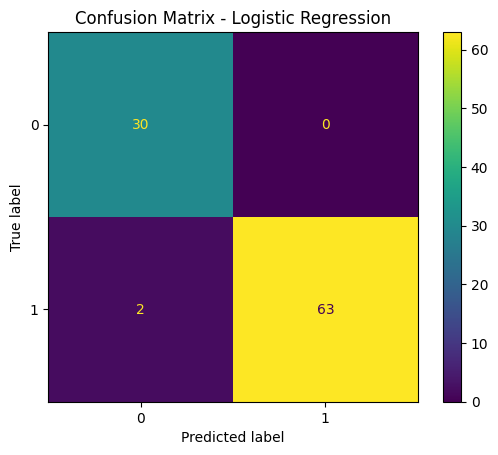

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Convert Spark → Pandas
pred_pd = predictions.select("label", "prediction").toPandas()

# True & Predicted
y_true = pred_pd["label"]
y_pred = pred_pd["prediction"]

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# **Clustering**

Silhouette Score: 0.6448079289144515
+----------+
|prediction|
+----------+
|         1|
|         1|
|         1|
|         1|
|         1|
|         1|
|         1|
|         1|
|         1|
|         1|
+----------+
only showing top 10 rows


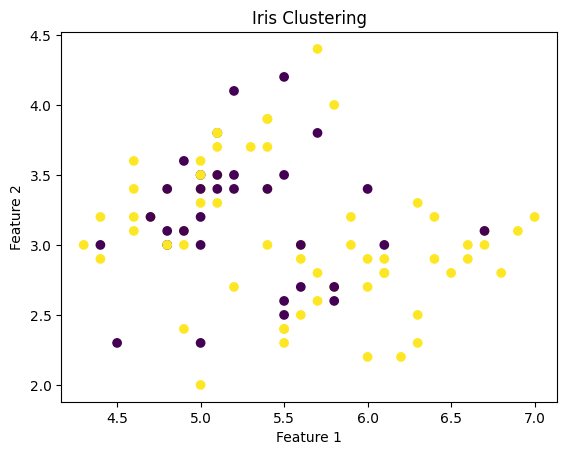

In [21]:
from sklearn.datasets import load_iris
import pandas as pd

from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import ClusteringEvaluator

# Load dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

spark_df = spark.createDataFrame(df)

# Pipeline
assembler = VectorAssembler(inputCols=iris.feature_names, outputCol="features_raw")
scaler = StandardScaler(inputCol="features_raw", outputCol="features")
kmeans = KMeans(k=3, seed=42)

pipeline = Pipeline(stages=[assembler, scaler, kmeans])

# Train
model = pipeline.fit(spark_df)

# Predict
predictions = model.transform(spark_df)

# Evaluate
evaluator = ClusteringEvaluator()
score = evaluator.evaluate(predictions)

print("Silhouette Score:", score)
predictions.select("prediction").show(10)
iris_pd = df.copy()
iris_pd["cluster"] = pred_pd["prediction"]

plt.scatter(iris_pd.iloc[:, 0], iris_pd.iloc[:, 1], c=iris_pd["cluster"])
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Iris Clustering")
plt.show()


****

# **Recommendation System**

Dataset Loaded
+------+------+------+
|userId|itemId|rating|
+------+------+------+
|   196|   242|     3|
|   186|   302|     3|
|    22|   377|     1|
|   244|    51|     2|
|   166|   346|     1|
+------+------+------+
only showing top 5 rows
Predictions:
+------+------+------+----------+
|userId|itemId|rating|prediction|
+------+------+------+----------+
|   148|   116|     5| 3.9192863|
|   148|   132|     4|  4.568192|
|   148|   163|     4|  3.963992|
|   148|   172|     5| 4.8666644|
|   148|   228|     4| 4.0908628|
|   148|   357|     5| 4.1503334|
|   148|   496|     3|  4.153003|
|   148|   509|     5| 4.3623037|
|   148|   549|     3| 3.8456557|
|   463|     3|     2| 1.3074586|
+------+------+------+----------+
only showing top 10 rows
RMSE: 0.9216686226306633
MAE: 0.7303948734627027
Top 3 Recommendations for each User:
+------+---------------------------------------------------------+
|userId|recommendations                                          |
+------+------------

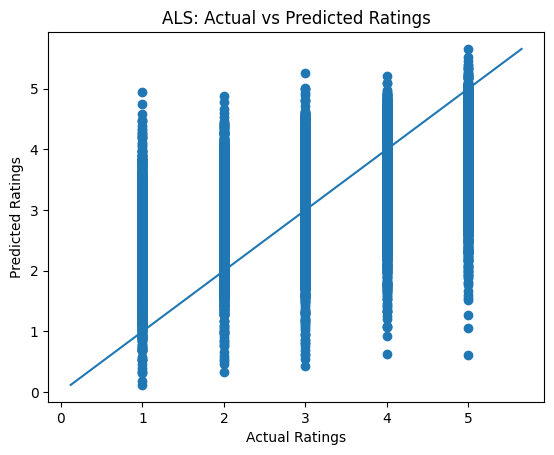

In [22]:
url = "https://files.grouplens.org/datasets/movielens/ml-100k/u.data"

df = pd.read_csv(url, sep="\t", names=["userId", "itemId", "rating", "timestamp"])

# Drop timestamp
df = df.drop("timestamp", axis=1)

# Convert to Spark
spark_df = spark.createDataFrame(df)

print("Dataset Loaded")
spark_df.show(5)

train, test = spark_df.randomSplit([0.8, 0.2], seed=42)


from pyspark.ml.recommendation import ALS

als = ALS(
    userCol="userId",
    itemCol="itemId",
    ratingCol="rating",
    coldStartStrategy="drop"
)

model = als.fit(train)


predictions = model.transform(test)
print("Predictions:")
predictions.select("userId", "itemId", "rating", "prediction").show(10)

from pyspark.ml.evaluation import RegressionEvaluator

rmse_evaluator = RegressionEvaluator(
    metricName="rmse",
    labelCol="rating",
    predictionCol="prediction"
)

mae_evaluator = RegressionEvaluator(
    metricName="mae",
    labelCol="rating",
    predictionCol="prediction"
)

rmse = rmse_evaluator.evaluate(predictions)
mae = mae_evaluator.evaluate(predictions)

print("RMSE:", rmse)
print("MAE:", mae)


print("Top 3 Recommendations for each User:")
user_recs = model.recommendForAllUsers(3)
user_recs.show(truncate=False)

print("Top 3 Users for each Item:")
item_recs = model.recommendForAllItems(3)
item_recs.show(truncate=False)
pred_pd = predictions.select("rating", "prediction").dropna().toPandas()

plt.scatter(pred_pd["rating"], pred_pd["prediction"])

plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("ALS: Actual vs Predicted Ratings")

# Diagonal reference line
min_val = min(pred_pd["rating"].min(), pred_pd["prediction"].min())
max_val = max(pred_pd["rating"].max(), pred_pd["prediction"].max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()